This is the supplementary materials for you to complete your assignment 1

This is an example that help your group to complete assignment 1, feel free to change any of the content.

First of all neccesary imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder,LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from termcolor import colored

# Keras and TensorFlow for building the deep learning model
import keras
import tensorflow as tf
# from keras.preprocessing import text
# from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM,Dropout
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer

# Natural Language Toolkit for text processing
import nltk
from nltk.corpus import stopwords
from textblob import Word
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
from nltk.corpus import wordnet

from warnings import filterwarnings
filterwarnings('ignore')

from sklearn import set_config
set_config(print_changed_only = False)
%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Let's read the data from csv file

In [ ]:
sms = pd.read_csv('spam.csv', encoding='latin-1')
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Now drop "unnamed" columns and rename v1 and v2 to "label" and "message"

In [ ]:
sms = sms.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)
sms = sms.rename(columns = {'v1':'label','v2':'message'})

Let's look into our data

In [ ]:
sms.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

Intresting that "Sorry, I'll call later" appears only 30 times here =)

Now let's create new feature "message length" and plot it to see if it's of any interest

In [ ]:
sms['length'] = sms['message'].apply(len)
sms.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


### Text processing and vectorizing our meddages

Let's create new data frame. We'll need a copy later on

In [ ]:
text_feat = sms['message'].copy()

Now define our tex precessing function. It will remove any punctuation and stopwords aswell.

In [ ]:
def text_process(text):

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = [word for word in text.split() if word.lower() not in stopwords.words('english')]

    return " ".join(text)

In [ ]:
import nltk
nltk.download('stopwords')
text_feat = text_feat.apply(text_process)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
features = vectorizer.fit_transform(text_feat)

###  Classifiers and predictions

First of all let's split our features to test and train set. In your assignment, you can describe why you plan to split like this? Is there anything  you can improve?

In [ ]:
x_train, x_test , y_train, y_test = train_test_split(features, sms['label'], test_size=0.3, random_state=111)

Now let's import bunch of classifiers, initialize them and make a dictionary to itereate through. In you assignment, you do not need to list them all. I would like recommend you describing each classifier you imported, and discuss the result.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

Following are some parameters in classification. In you assignment, you can try to adjust those parameters and observe their results. I would like to suggest you to discuss some links between the parameters and results.

In [ ]:
svc = SVC(kernel='linear', gamma=1.0)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
mlp = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)

In [ ]:
clfs = {'SVC' : svc,'LR': lrc, 'MLP': mlp}

Let's make functions to fit our classifiers and make predictions

In [ ]:
def train_classifier(clf, x_train, y_train):
    clf.fit(x_train, y_train)

In [ ]:
def predict_labels(clf, features):
    return (clf.predict(features))

Now iterate through classifiers and save the results

In [ ]:
#pred_scores = []
#for k,v in clfs.items():
 #   train_classifier(v, x_train, y_train)
  #  pred = predict_labels(v,x_test)
   # pred_scores.append((k, f"Accuracy: {[accuracy_score(y_test,pred)]} Precision: {[precision_score(y_test,pred)]} Recall: {[recall_score(y_test,pred)]} F1 Score: {[f1_score(y_test,pred)]}"))
pred_scores = []
for k,v in clfs.items():
    train_classifier(v, x_train, y_train)
    pred = predict_labels(v,x_test)
    pred_scores.append((k, [accuracy_score(y_test,pred)]))
    pred_scores.append(confusion_matrix(y_test, pred))

Now you can see the result

In [ ]:
pred_scores

[('SVC', [0.9796650717703349]),
 array([[1438,    2],
        [  32,  200]]),
 ('LR', [0.9431818181818182]),
 array([[1425,   15],
        [  80,  152]]),
 ('MLP', [0.9635167464114832]),
 array([[1440,    0],
        [  61,  171]])]

Use a dataframe to present them.

[[1440    0]
 [  61  171]]


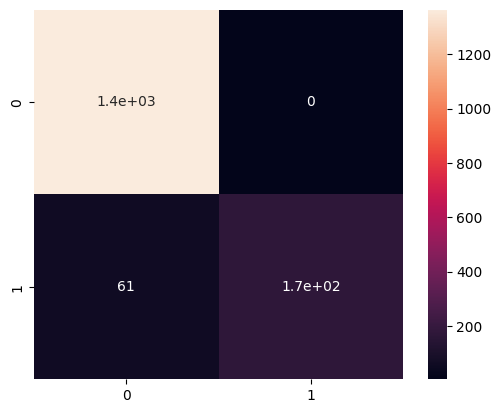

In [ ]:
pred = predict_labels(clfs['MLP'], x_test)
conf_mat = confusion_matrix(y_test, pred)
print(conf_mat)

sns.heatmap(conf_mat, square = True, annot = True, robust = True)
plt.show()

[[1425   15]
 [  80  152]]


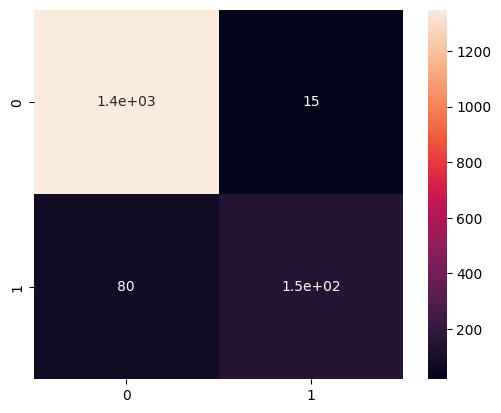

In [ ]:
pred = predict_labels(clfs['LR'], x_test)
conf_mat = confusion_matrix(y_test, pred)
print(conf_mat)

sns.heatmap(conf_mat, square = True, annot = True, robust = True)
plt.show()

[[1438    2]
 [  32  200]]


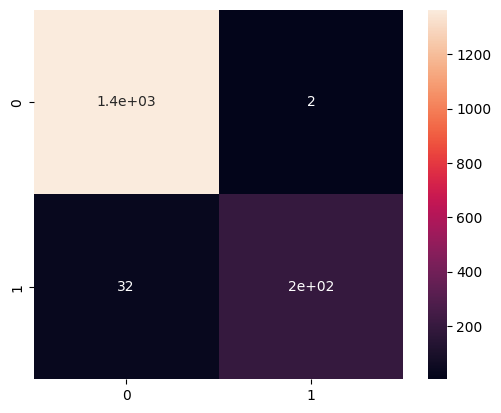

In [ ]:
pred = predict_labels(clfs['SVC'], x_test)
conf_mat = confusion_matrix(y_test, pred)
print(conf_mat)

sns.heatmap(conf_mat, square = True, annot = True, robust = True)
plt.show()

Looks like ensemble classifiers are not doing as good as expected.

In you assignment, I would like recommend to plot them in a co-ordinator.

In [ ]:
spam_clf = LogisticRegression(solver = 'liblinear', max_iter = 10000)

spam_clf.fit(x_train, y_train)

print(spam_clf.score(x_train, y_train))

0.9623076923076923


In [ ]:
k = 5
scores = cross_val_score(spam_clf, x_train, y_train, cv = k)

print('\033[1m Scores: \033[0m' + (k * '{:.3f} ').format(*scores))
print('\033[1m Average: \033[0m', scores.mean())

NameError: name 'cross_val_score' is not defined

Logistical Regression

In [ ]:
lr_model = LogisticRegression(C=0.1, solver='liblinear', max_iter=500)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

svm_model = SVC(C=10.0, kernel='rbf', gamma='auto')
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)

SVM

In [ ]:
lr_accuracy = accuracy_score(y_test, pred)
lr_precision = precision_score(y_test, pred, average='weighted')
lr_recall = recall_score(y_test, pred, average='weighted')
lr_conf_matrix = confusion_matrix(y_test, pred)

svm_accuracy = accuracy_score(y_test, pred)
svm_precision = precision_score(y_test, pred, average='weighted')
svm_recall = recall_score(y_test, pred, average='weighted')
svm_conf_matrix = confusion_matrix(y_test, pred)

In [ ]:
print("Logistic Regression:")
print(f"Accuracy: {lr_accuracy}, \nPrecision: {lr_precision}, \nRecall: {lr_recall}")
print(f"The Confusion matrix is \n{lr_conf_matrix}")
print("\n")
print("SVM:")
print(f"Accuracy: {svm_accuracy}, \nPrecision: {svm_precision}, \nRecall: {svm_recall}")
print(f"The Confusion matrix is \n{svm_conf_matrix}")
print("\n")


Logistic Regression:
Accuracy: 0.9635167464114832, 
Precision: 0.9649994102815029, 
Recall: 0.9635167464114832
The Confusion matrix is 
[[1440    0]
 [  61  171]]


SVM:
Accuracy: 0.9635167464114832, 
Precision: 0.9649994102815029, 
Recall: 0.9635167464114832
The Confusion matrix is 
[[1440    0]
 [  61  171]]




MLP

In [ ]:
lb = LabelEncoder()
sms["label"] = lb.fit_transform(sms["label"])

In [ ]:
x = sms["message"]
y = sms["label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, shuffle = True, random_state = 11)

print(colored("\nDATASET WAS SUCCESFULLY DIVIDED ...", color = "green", attrs = ["bold", "dark"]))

In [ ]:
print("The shape of 'train_x' is {} and the shape of 'test_x' is {}".format(x_train.shape[0], x_test.shape[0]))

In [ ]:
tokenizer = Tokenizer(num_words = 6013)
tokenizer.fit_on_texts(x_train)

tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_test = tokenizer.texts_to_sequences(x_test)

x_train = pad_sequences(tokenized_train, maxlen = None)
x_test = pad_sequences(tokenized_test, maxlen = None)

# Checking the length of each sequence in train_x and test_x
train_lengths = [len(x) for x in x_train]
test_lengths = [len(x) for x in x_test]

# Printing basic statistics about sequence lengths
print(f"Training lengths: Min={min(train_lengths)}, Max={max(train_lengths)}, Avg={sum(train_lengths)/len(train_lengths)}")
print(f"Testing lengths: Min={min(test_lengths)}, Max={max(test_lengths)}, Avg={sum(test_lengths)/len(test_lengths)}")

In [ ]:
GLOVE_EMBEDDING = "glove.twitter.27B.100d.txt"

In [ ]:
import numpy as np

def get_coefs(word, *arr):
    return word, np.asarray(arr, dtype='float64')

embeddings_index = {}
VECTOR_SIZE = None  # We will determine this dynamically from the first vector

with open(GLOVE_EMBEDDING, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        word, coefs = get_coefs(*line.rstrip().split(" "))
        if VECTOR_SIZE is None:
            VECTOR_SIZE = len(coefs)
            print(f"Detected vector size: {VECTOR_SIZE}")
        if len(coefs) == VECTOR_SIZE:
            embeddings_index[word] = coefs
        else:
            # If the vector is not of the expected size, we can choose to pad or ignore it.
            # Here we pad shorter vectors with zeros
            if len(coefs) < VECTOR_SIZE:
                print(f"Padding vector for {word} from length {len(coefs)} to {VECTOR_SIZE}")
                padded_coefs = np.zeros(VECTOR_SIZE)
                padded_coefs[:len(coefs)] = coefs
                embeddings_index[word] = padded_coefs
            else:
                print(f"Ignoring vector for {word} due to incorrect size {len(coefs)}")

# Assuming we now have a properly formatted embeddings_index with vectors of the same size
embeddings = np.stack(list(embeddings_index.values()))

In [ ]:
embedding_mean, embedding_std = embeddings.mean(), embeddings.std()
embedding_size = embeddings.shape[1]

# Assuming tokenizer is defined elsewhere and has a word_index attribute
word_index = tokenizer.word_index
nb_words = min(6012, len(word_index)) + 1

# Initialize the embedding matrix
embedding_matrix = np.random.normal(embedding_mean, embedding_std, (nb_words, embedding_size))
for word, i in word_index.items():
    if i >= 6012:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
print(embedding_matrix)
print(embedding_matrix.shape)

In [ ]:
lr_reduce = ReduceLROnPlateau(monitor = "val_accuracy", patience = 2, factor = 0.5, min_lr = 0.00001)

In [ ]:
mlp = Sequential()

mlp.add(Embedding(6013, output_dim = 100, weights = [embedding_matrix], trainable = False))

mlp.add(LSTM(units = 128, return_sequences = True, recurrent_dropout = 0.3, dropout = 0.5))

mlp.add(LSTM(units = 64, recurrent_dropout = 0.3, dropout = 0.5))

mlp.add(Dense(units = 32, activation = "relu"))

mlp.add(Dense(1, activation = "sigmoid"))

mlp.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), loss = "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
mlp.summary()

In [ ]:
history = mlp.fit(x_train, y_train, batch_size=64, validation_data=(x_test, y_test), epochs=4, callbacks = [lr_reduce])

In [ ]:
epochs = [i for i in range(10)]

fig, ax = plt.subplots(1, 2)
train_acc = history.history["accuracy"]
train_loss = history.history["loss"]
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]
fig.set_size_inches(20, 10)

ax[0].plot(epochs, train_acc, "go-", label = "Train accuracy")
ax[0].plot(epochs, val_acc, "ro-", label = "Test accuracy")
ax[0].set_title("Train and test accuracy")
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, "go-", label = "Train loss")
ax[1].plot(epochs, val_loss, "ro-", label = "Test loss")
ax[1].set_title("Train and test loss")
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

Scores

In [ ]:
svc = SVC(kernel='linear', gamma=1.0)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
model = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)

In [ ]:
clfs = {'SVC' : svc,'LR': lrc, 'MLP': model}

In [ ]:
def train_classifier(clf, feature_train, labels_train):
    clf.fit(feature_train, labels_train)

In [ ]:
def predict_labels(clf, features):
    return (clf.predict(features))

In [ ]:
pred_scores = []
for k,v in clfs.items():
    train_classifier(v, x_train, y_train)
    pred = predict_labels(v,x_test)
    pred_scores.append((k, [accuracy_score(y_test,pred)]))
    pred_scores.append((k, [classification_report(y_test,pred)]))

In [ ]:
pred_scores

LTSM

In [ ]:
prediction = model.predict(x_test)
classes_pred = (prediction >= 0.5).astype(int)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, classes_pred)

print(f"Accuracy: {accuracy}")
print(classification_report(y_test, classes_pred))

In [ ]:
x_train = x_train.reshape(-1, x_train.shape[1] * x_train.shape[2]) if len(x_train.shape) > 2 else x_train

classes_pred = model.predict(x_test)
mlp_pred = (classes_pred >= 0.5).astype(int)
#mlp_model = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)
mlp_model.fit(x_train, y_train)
mlp_pred = mlp_model.predict(x_test)


mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred, average='weighted')
mlp_recall = recall_score(y_test, mlp_pred, average='weighted')
mlp_conf_matrix = confusion_matrix(y_test, mlp_pred)

print(f"Accuracy: {mlp_accuracy}")
print(classification_report(y_test, mlp_pred))
#print(classification_report(mlp_accuracy, mlp_precision, mlp_recall))
print(mlp_conf_matrix)

Logistical Regression

In [ ]:
lr_model = LogisticRegression(C=0.1, solver='liblinear', max_iter=500)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_conf_matrix = confusion_matrix(y_test, lr_pred)

print(classification_report(y_test, classes_pred))

SVM

In [ ]:
svm_model = SVC(C=10.0, kernel='rbf', gamma='auto')
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_conf_matrix = confusion_matrix(y_test, svm_pred)

print(classification_report(y_test, classes_pred))